In [844]:
#importing the dataset given by the japeto

In [376]:
import pandas as pd
dataset= pd.read_excel("chatbot_dataset.xlsx")
dataset

,session_id,message_time,user_message,chatbot_response,response_source,categories,intent_name
0,526919,2025-02-06 06:31:46,timezone test,"I'm happy to chat with you, but I'm a sales an...",Generative AI,Other,AI generated
1,526920,2025-02-06 06:32:00,how r u,I'm an AI Assistant... I don't know how I am. ...,NLU,General conversation,How are you
2,526920,2025-02-06 06:32:16,im awful,I'm sorry to hear that. \n\nAre you having an ...,NLU,Other,Answers question about self negatively
3,526920,2025-02-06 06:32:17,nope,I'm happy to assist you with any questions you...,Generative AI,General conversation,AI generated
4,526921,2025-02-06 06:32:32,hello paige,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,Services,Hello
...,...,...,...,...,...,...,...
1353,536274,2025-02-11 21:36:22,hello,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,General conversation,Hello
1354,536274,2025-02-11 21:36:20,are you london based,I'm afraid I'm unable to answer that question ...,Generative AI,About Japeto,AI generated
1355,536274,2025-02-11 21:36:46,we're looking for uk development agency for in...,You're looking for a UK-based development agen...,Generative AI,Services,AI generated
1356,536276,2025-02-11 21:37:05,Hello how ar eyou,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,General conversation,Hello


In [377]:
#checking if there are any null vlaues
dataset.isnull()
dataset.isnull().sum()
dataset.duplicated().sum()
dataset.drop_duplicates()

,session_id,message_time,user_message,chatbot_response,response_source,categories,intent_name
0,526919,2025-02-06 06:31:46,timezone test,"I'm happy to chat with you, but I'm a sales an...",Generative AI,Other,AI generated
1,526920,2025-02-06 06:32:00,how r u,I'm an AI Assistant... I don't know how I am. ...,NLU,General conversation,How are you
2,526920,2025-02-06 06:32:16,im awful,I'm sorry to hear that. \n\nAre you having an ...,NLU,Other,Answers question about self negatively
3,526920,2025-02-06 06:32:17,nope,I'm happy to assist you with any questions you...,Generative AI,General conversation,AI generated
4,526921,2025-02-06 06:32:32,hello paige,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,Services,Hello
...,...,...,...,...,...,...,...
1353,536274,2025-02-11 21:36:22,hello,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,General conversation,Hello
1354,536274,2025-02-11 21:36:20,are you london based,I'm afraid I'm unable to answer that question ...,Generative AI,About Japeto,AI generated
1355,536274,2025-02-11 21:36:46,we're looking for uk development agency for in...,You're looking for a UK-based development agen...,Generative AI,Services,AI generated
1356,536276,2025-02-11 21:37:05,Hello how ar eyou,Hi! Thanks for chatting. I'm an AI Assistant f...,NLU,General conversation,Hello


In [378]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   session_id        1358 non-null   int64 
 1   message_time      1358 non-null   object
 2   user_message      1358 non-null   object
 3   chatbot_response  1358 non-null   object
 4   response_source   1358 non-null   object
 5   categories        1358 non-null   object
 6   intent_name       1358 non-null   object
dtypes: int64(1), object(6)
memory usage: 74.4+ KB


In [382]:
dataset.shape

(1358, 7)

In [384]:
#deleting the colums wich are not necessary for the predictions
dataset.drop('message_time',axis=1 ,inplace=True)
dataset.drop('intent_name',axis=1 ,inplace=True)
dataset.drop('session_id',axis=1 ,inplace=True)
dataset.drop('response_source',axis=1 ,inplace=True)

In [386]:
dataset

,user_message,chatbot_response,categories
0,timezone test,"I'm happy to chat with you, but I'm a sales an...",Other
1,how r u,I'm an AI Assistant... I don't know how I am. ...,General conversation
2,im awful,I'm sorry to hear that. \n\nAre you having an ...,Other
3,nope,I'm happy to assist you with any questions you...,General conversation
4,hello paige,Hi! Thanks for chatting. I'm an AI Assistant f...,Services
...,...,...,...
1353,hello,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation
1354,are you london based,I'm afraid I'm unable to answer that question ...,About Japeto
1355,we're looking for uk development agency for in...,You're looking for a UK-based development agen...,Services
1356,Hello how ar eyou,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation


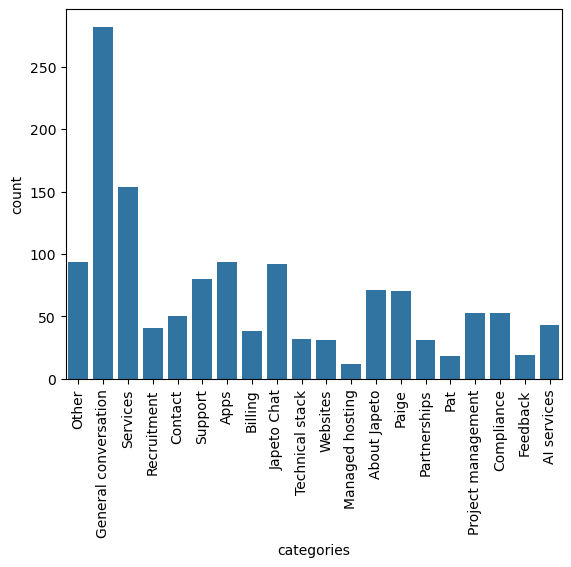

<Figure size 1500x1000 with 0 Axes>

In [388]:
#visualisation for the dataset with respect to categories
#importing seaborm library and matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='categories', data=dataset)

# Rotating x-axis labels for readability
plt.xticks(rotation=90)

plt.figure(figsize=(15,10))  

plt.show()

In [391]:
dataset

,user_message,chatbot_response,categories
0,timezone test,"I'm happy to chat with you, but I'm a sales an...",Other
1,how r u,I'm an AI Assistant... I don't know how I am. ...,General conversation
2,im awful,I'm sorry to hear that. \n\nAre you having an ...,Other
3,nope,I'm happy to assist you with any questions you...,General conversation
4,hello paige,Hi! Thanks for chatting. I'm an AI Assistant f...,Services
...,...,...,...
1353,hello,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation
1354,are you london based,I'm afraid I'm unable to answer that question ...,About Japeto
1355,we're looking for uk development agency for in...,You're looking for a UK-based development agen...,Services
1356,Hello how ar eyou,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation


In [393]:
# used the language tool api to correct any grammatical error in the user messages

In [395]:
import pandas as pd
import requests

# Function to check and correct grammatical errors
def check_grammar(text):
    url = 'https://api.languagetool.org/v2/check'
    params = {
        'text': text,
        'language': 'en-US',  
    }
    
    # Sending the request to the API
    response = requests.post(url, data=params)
    
    # If the response status is OK, extracting the corrected text
    if response.status_code == 200:
        result = response.json()
        corrected_text = text
        
        # Correct the errors in the text based on the suggestions
        for match in result['matches']:
            offset = match['offset']
            length = match['length']
            
        
            if match['replacements']:
                replacement = match['replacements'][0]['value']
                # Replacing the incorrect part of the text with the suggested correction
                corrected_text = corrected_text[:offset] + replacement + corrected_text[offset+length:]
        
        return corrected_text
    else:
        return text  




dataset['user_message'] = dataset['user_message'].apply(check_grammar)

print(dataset)


                                           user_message  \
0                                         Timezone test   
1                                               How r u   
2                                             I'm awful   
3                                                  nope   
4                                           Hello Paige   
...                                                 ...   
1353                                              hello   
1354                               Are you London based   
1355  We're looking for UK development agency for in...   
1356                                 Hello, howare youu   
1357                              kasfouwoe asdfasdfadf   

                                       chatbot_response            categories  
0     I'm happy to chat with you, but I'm a sales an...                 Other  
1     I'm an AI Assistant... I don't know how I am. ...  General conversation  
2     I'm sorry to hear that. \n\nAre you having an

In [397]:
dataset.shape

(1358, 3)

In [372]:
import pandas as pd
import random
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet')

# Load dataset
df = dataset 

# Function to replace words with synonyms
def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    
    if len(random_word_list) == 0:
        return sentence  # No synonyms found, return original

    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1

        if num_replaced >= n:
            break

    return ' '.join(new_words)

# Apply augmentation
df_augmented = df.copy()
df_augmented["user_message"] = df["user_message"].apply(lambda x: synonym_replacement(x))

# Combine original and augmented data
dataset = pd.concat([df, df_augmented]).reset_index(drop=True)

print("Original Data Size:", df.shape)
print("Augmented Data Size:", dataset.shape)

# Save new dataset
#df_final.to_csv("augmented_data.csv", index=False)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dheer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original Data Size: (1358, 3)
Augmented Data Size: (2716, 3)


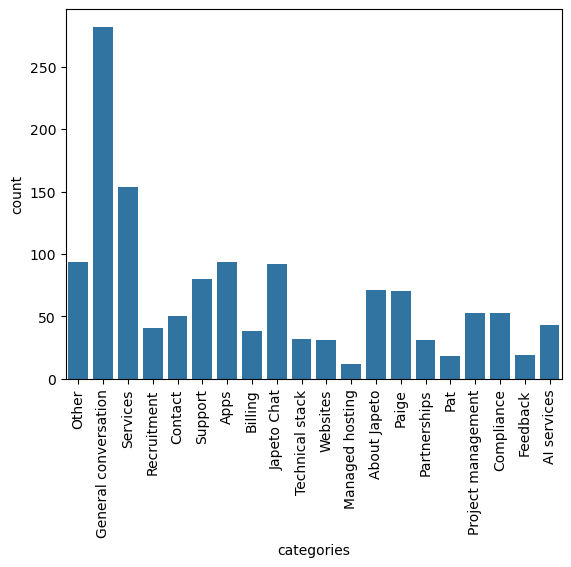

<Figure size 1500x1000 with 0 Axes>

In [399]:
#visualisation for the dataset with respect to categories
#importing seaborm library and matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='categories', data=dataset)

# Rotating x-axis labels for readability
plt.xticks(rotation=90)

plt.figure(figsize=(15,10))  

plt.show()


In [244]:
 dataset

,user_message,chatbot_response,categories
0,Timezone test,"I'm happy to chat with you, but I'm a sales an...",Other
1,How r u,I'm an AI Assistant... I don't know how I am. ...,General conversation
2,I'm awful,I'm sorry to hear that. \n\nAre you having an ...,Other
3,nope,I'm happy to assist you with any questions you...,General conversation
4,Hello Paige,Hi! Thanks for chatting. I'm an AI Assistant f...,Services
...,...,...,...
2711,hello,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation
2712,are you London based,I'm afraid I'm unable to answer that question ...,About Japeto
2713,We're looking for UK development agency for in...,You're looking for a UK-based development agen...,Services
2714,hello how are you,Hi! Thanks for chatting. I'm an AI Assistant f...,General conversation


In [401]:
#preprocessing the datasets for user_message and chatbot_response

import re
from string import punctuation

def pre_process_text(text):

    processed_text = text.lower()
    processed_text =  re.sub(f"[{re.escape(punctuation)}]", "", processed_text)
    processed_text = " ".join(processed_text.split())
    return processed_text

dataset["user_message"] = dataset["user_message"].apply(lambda x:pre_process_text(x))
dataset["chatbot_response"] = dataset["chatbot_response"].apply(lambda x:pre_process_text(x))
dataset

,user_message,chatbot_response,categories
0,timezone test,im happy to chat with you but im a sales and s...,Other
1,how r u,im an ai assistant i dont know how i am i do n...,General conversation
2,im awful,im sorry to hear that are you having an issues...,Other
3,nope,im happy to assist you with any questions you ...,General conversation
4,hello paige,hi thanks for chatting im an ai assistant for ...,Services
...,...,...,...
1353,hello,hi thanks for chatting im an ai assistant for ...,General conversation
1354,are you london based,im afraid im unable to answer that question as...,About Japeto
1355,were looking for uk development agency for inn...,youre looking for a ukbased development agency...,Services
1356,hello howare youu,hi thanks for chatting im an ai assistant for ...,General conversation


In [403]:
#stemming of the data
#import nltk 
from nltk.tokenize import word_tokenize
#from nltk.stem import PorterStemmer
#nltk.download('punkt_tab')

#def stemming(text):
    
#     tokens = word_tokenize(text)

#     ps = PorterStemmer()
#     required_words = [ps.stem(x) for x in tokens ]

#     sentence_with_stemmed_words = ' '.join(required_words)

#     return sentence_with_stemmed_words

#dataset["user_message"] = dataset["user_message"].apply(lambda x:stemming(x))
#dataset["chatbot_response"] = dataset["chatbot_response"].apply(lambda x:stemming(x))
#dataset

In [405]:
#lemmatisation of the data
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

def lemmatization(text):
    wordnet_lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    required_words = [wordnet_lemmatizer.lemmatize(x, 'v') for x in  tokens]
    sentence_with_lemmnatized_word = " ".join(required_words)
    
    return sentence_with_lemmnatized_word

dataset["user_message"] = dataset["user_message"].apply(lambda x:lemmatization(x))
dataset["chatbot_response"] = dataset["chatbot_response"].apply(lambda x:lemmatization(x))
dataset


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dheer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,user_message,chatbot_response,categories
0,timezone test,im happy to chat with you but im a sales and s...,Other
1,how r u,im an ai assistant i dont know how i be i do n...,General conversation
2,im awful,im sorry to hear that be you have an issue i c...,Other
3,nope,im happy to assist you with any question you m...,General conversation
4,hello paige,hi thank for chat im an ai assistant for japet...,Services
...,...,...,...
1353,hello,hi thank for chat im an ai assistant for japet...,General conversation
1354,be you london base,im afraid im unable to answer that question as...,About Japeto
1355,be look for uk development agency for innovate...,youre look for a ukbased development agency to...,Services
1356,hello howare youu,hi thank for chat im an ai assistant for japet...,General conversation


In [407]:
#removing of the stop words 
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

def get_stop_words():
    return set(stopwords.words('english'))
    
    
def remove_stop_words(text):
    stop_words = get_stop_words()
    tokens = word_tokenize(text)
    filtered_words = [x for x in tokens if x not in stop_words]
    sentences_without_stop_words = " ".join(filtered_words)
    return sentences_without_stop_words

dataset["user_message"] = dataset["user_message"].apply(lambda x:remove_stop_words(x))
dataset["chatbot_response"] = dataset["chatbot_response"].apply(lambda x:remove_stop_words(x))
dataset

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dheer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,user_message,chatbot_response,categories
0,timezone test,im happy chat im sales support chatbot japeto ...,Other
1,r u,im ai assistant dont know feel kid im okay liv...,General conversation
2,im awful,im sorry hear issue help,Other
3,nope,im happy assist question may japeto software d...,General conversation
4,hello paige,hi thank chat im ai assistant japeto give info...,Services
...,...,...,...
1353,hello,hi thank chat im ai assistant japeto give info...,General conversation
1354,london base,im afraid im unable answer question relate jap...,About Japeto
1355,look uk development agency innovate project,youre look ukbased development agency collabor...,Services
1356,hello howare youu,hi thank chat im ai assistant japeto give info...,General conversation


In [409]:
#vectorisation of the texts to an array
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range = (1, 1))
X = vectorizer.fit_transform(dataset["user_message"])
X = X.toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [411]:
Y = vectorizer.fit_transform(dataset["chatbot_response"])
Y = Y.toarray()
Y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [413]:
import numpy as np
# Concatenate user message and chatbot response vectors
a = np.hstack([Y, X])


In [415]:
a.shape


(1358, 3379)

In [417]:
from sklearn.model_selection import train_test_split

In [419]:
X_train, X_test, y_train, y_test = train_test_split(a, dataset["categories"], test_size=.2, random_state=10)

In [421]:
X_train.shape

(1086, 3379)

In [423]:
X_test.shape

(272, 3379)

In [425]:
y_train.shape

(1086,)

In [427]:
y_test.shape

(272,)

In [429]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [431]:
predictions = model.predict(X_test)

In [433]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy: ", accuracy*100, "%")

Accuracy:  58.45588235294118 %


In [435]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

accuracy = classification_report(y_test, predictions)

print(accuracy)

                      precision    recall  f1-score   support

         AI services       0.75      0.38      0.50         8
        About Japeto       1.00      0.06      0.11        17
                Apps       0.86      0.75      0.80        24
             Billing       1.00      0.33      0.50         9
          Compliance       1.00      0.67      0.80         9
             Contact       1.00      0.56      0.72        16
            Feedback       0.00      0.00      0.00         5
General conversation       0.48      1.00      0.65        51
         Japeto Chat       0.59      0.50      0.54        20
     Managed hosting       0.00      0.00      0.00         1
               Other       0.62      0.36      0.45        14
               Paige       1.00      0.60      0.75        10
        Partnerships       1.00      0.33      0.50         9
                 Pat       0.00      0.00      0.00         5
  Project management       1.00      0.36      0.53        11
       

C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [437]:
from sklearn.metrics import confusion_matrix
cmx = confusion_matrix(y_test, predictions)
print(cmx)

[[ 3  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  2  0  0  0]
 [ 0  1  0  0  0  0  0  8  0  0  1  0  0  0  0  0  7  0  0  0]
 [ 0  0 18  0  0  0  0  1  0  0  0  0  0  0  0  0  5  0  0  0]
 [ 0  0  0  3  0  0  0  2  0  0  0  0  0  0  0  0  1  3  0  0]
 [ 0  0  0  0  6  0  0  0  1  0  0  0  0  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  9  0  6  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 51  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  6 10  0  0  0  0  0  0  0  3  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  8  0  0  5  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  3  0  0  1  6  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  3  0  0  0  5  0  0  0]
 [ 0  0  0  0  0  0  0  4  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2  1  0  0  0  0  0  4  0  4  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  5  0  0

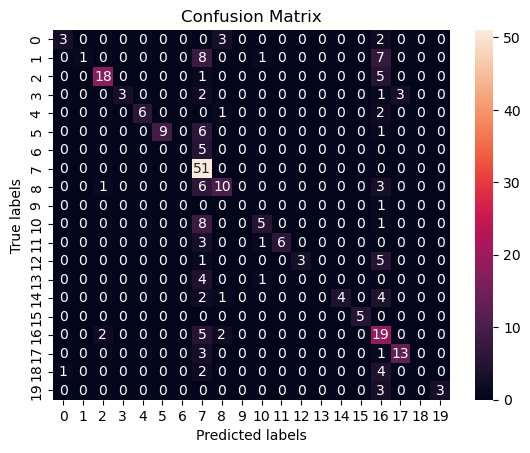

In [439]:
import seaborn as sbn
ax= plt.subplot()
sbn.heatmap(cmx, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
#ax.xaxis.set_ticklabels([3,4,5,6,7,8]); ax.yaxis.set_ticklabels([3,4,5,6,7,8]);

In [441]:
from sklearn.model_selection import KFold, cross_val_score

k_folds = KFold(n_splits = 10)

scores = cross_val_score(model,a,dataset["categories"], cv = k_folds)

print('Cross-validation scores:',scores)

Cross-validation scores: [0.58823529 0.63970588 0.625      0.52205882 0.65441176 0.54411765
 0.55882353 0.41911765 0.4962963  0.45925926]


In [443]:
from sklearn import tree
from sklearn.metrics import accuracy_score
clf = tree.DecisionTreeClassifier(criterion="entropy", max_depth=8)
clf = clf.fit(X_train, y_train)
predictions = clf.predict(X_test)
print(classification_report(y_test, predictions))

                      precision    recall  f1-score   support

         AI services       0.43      0.38      0.40         8
        About Japeto       0.00      0.00      0.00        17
                Apps       0.75      0.62      0.68        24
             Billing       0.33      0.11      0.17         9
          Compliance       0.60      0.67      0.63         9
             Contact       0.62      0.50      0.55        16
            Feedback       0.00      0.00      0.00         5
General conversation       0.68      0.84      0.75        51
         Japeto Chat       0.73      0.40      0.52        20
     Managed hosting       0.00      0.00      0.00         1
               Other       0.38      0.43      0.40        14
               Paige       0.60      0.60      0.60        10
        Partnerships       0.00      0.00      0.00         9
                 Pat       1.00      0.80      0.89         5
  Project management       0.50      0.36      0.42        11
       

In [445]:
from sklearn.neighbors import KNeighborsClassifier

In [447]:
knn =KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [449]:
y_pred = knn.predict(X_test)

In [451]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.51%


In [453]:
from sklearn.metrics import classification_report

predictions = knn.predict(X_test)

accuracy = classification_report(y_test, predictions)

print(accuracy)

                      precision    recall  f1-score   support

         AI services       0.40      0.50      0.44         8
        About Japeto       0.45      0.29      0.36        17
                Apps       0.72      0.75      0.73        24
             Billing       0.67      0.89      0.76         9
          Compliance       0.50      0.44      0.47         9
             Contact       0.90      0.56      0.69        16
            Feedback       0.67      0.40      0.50         5
General conversation       0.48      0.94      0.64        51
         Japeto Chat       0.58      0.35      0.44        20
     Managed hosting       1.00      1.00      1.00         1
               Other       0.14      0.21      0.17        14
               Paige       0.36      0.50      0.42        10
        Partnerships       1.00      0.56      0.71         9
                 Pat       1.00      0.80      0.89         5
  Project management       0.67      0.36      0.47        11
       

In [455]:
from sklearn.model_selection import KFold, cross_val_score

scores = cross_val_score(knn,a,dataset["categories"], cv = 10)

print('Cross-validation scores:',scores)

Cross-validation scores: [0.61029412 0.63235294 0.49264706 0.38970588 0.50735294 0.45588235
 0.55882353 0.49264706 0.48148148 0.48148148]


In [457]:
from sklearn.metrics import confusion_matrix
cmx = confusion_matrix(y_test, y_pred)
print(cmx)

[[ 4  0  0  0  1  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  5  1  0  0  0  0  4  0  0  5  0  0  0  0  0  1  0  0  0]
 [ 0  0 18  0  0  0  0  3  1  0  0  0  0  0  1  0  1  0  0  0]
 [ 0  0  0  8  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  4  0  0  3  0  0  1  1  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  9  0  3  0  0  1  1  0  0  0  0  1  0  0  0]
 [ 0  1  0  0  0  0  2  1  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0 48  0  0  1  0  0  0  1  0  0  0  0  0]
 [ 2  0  2  1  0  0  0  4  7  0  0  4  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  8  1  0  3  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2  0  0  2  5  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  3  0  0  1  0  5  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  4  0  0  0  0  0  0]
 [ 0  0  2  0  1  0  1  2  0  0  0  1  0  0  4  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  4  0  0

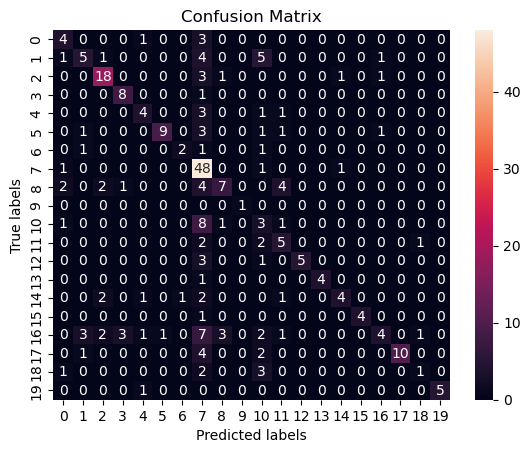

In [459]:
import seaborn as sbn
ax= plt.subplot()
sbn.heatmap(cmx, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
#ax.xaxis.set_ticklabels([3,4,5,6,7,8]); ax.yaxis.set_ticklabels([3,4,5,6,7,8]);

In [461]:
from sklearn.linear_model import LogisticRegression

In [463]:
log_reg_classifier = LogisticRegression(max_iter=1000, multi_class='ovr', solver='liblinear')

In [465]:
log_reg_classifier.fit(X_train, y_train)

C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr', solver='liblinear')

In [467]:
y_pred = log_reg_classifier.predict(X_test)


In [469]:
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print(classification_report(y_test, y_pred))

Accuracy: 70.22%
                      precision    recall  f1-score   support

         AI services       0.80      0.50      0.62         8
        About Japeto       1.00      0.29      0.45        17
                Apps       0.91      0.83      0.87        24
             Billing       1.00      0.78      0.88         9
          Compliance       0.75      0.67      0.71         9
             Contact       1.00      0.56      0.72        16
            Feedback       1.00      0.20      0.33         5
General conversation       0.71      0.98      0.83        51
         Japeto Chat       0.68      0.75      0.71        20
     Managed hosting       0.00      0.00      0.00         1
               Other       0.38      0.64      0.47        14
               Paige       0.67      0.60      0.63        10
        Partnerships       1.00      0.44      0.62         9
                 Pat       1.00      0.60      0.75         5
  Project management       0.88      0.64      0.74 

C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [471]:
from sklearn.metrics import confusion_matrix
cmx = confusion_matrix(y_test, y_pred)
print(cmx)

[[ 4  0  0  0  1  0  0  0  2  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  5  0  0  0  0  0  2  0  0  4  1  0  0  0  0  5  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  1  0  0  0  1  0  2  0  0  0]
 [ 0  0  0  7  0  0  0  1  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0  0  0  0  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  9  0  2  0  0  1  0  0  0  0  0  4  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  2  0  0  0  0  0  1  1  0  0]
 [ 0  0  0  0  0  0  0 50  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  1 15  0  1  1  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  4  1  0  9  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  2  0  0  1  6  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  5  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  1  0  0  3  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0  0  7  0  2  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  5  0  0

In [473]:
from sklearn.model_selection import KFold, cross_val_score

scores = cross_val_score(log_reg_classifier,a,dataset["categories"], cv = 10)

print('Cross-validation scores:',scores)

C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_clas

Cross-validation scores: [0.69117647 0.71323529 0.68382353 0.69852941 0.66911765 0.69117647
 0.76470588 0.72794118 0.7037037  0.67407407]


C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


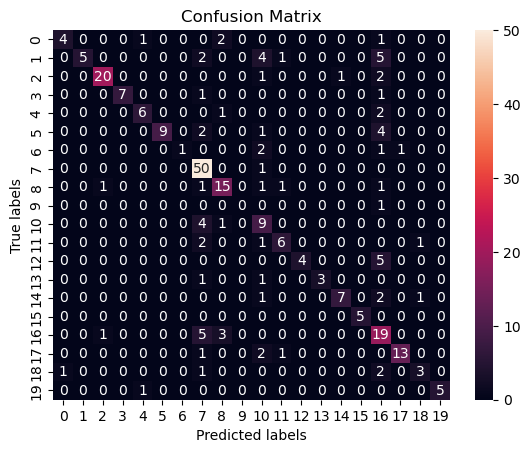

In [475]:
import seaborn as sbn
ax= plt.subplot()
sbn.heatmap(cmx, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
#ax.xaxis.set_ticklabels([3,4,5,6,7,8]); ax.yaxis.set_ticklabels([3,4,5,6,7,8]);

In [477]:
from sklearn.ensemble import RandomForestClassifier

In [479]:
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [481]:
random_forest_classifier.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [482]:
y_pred = random_forest_classifier.predict(X_test)

# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# 8. Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 68.01%
Classification Report:
                      precision    recall  f1-score   support

         AI services       0.75      0.38      0.50         8
        About Japeto       0.73      0.47      0.57        17
                Apps       0.90      0.79      0.84        24
             Billing       0.88      0.78      0.82         9
          Compliance       0.73      0.89      0.80         9
             Contact       0.91      0.62      0.74        16
            Feedback       0.00      0.00      0.00         5
General conversation       0.65      0.98      0.78        51
         Japeto Chat       0.65      0.55      0.59        20
     Managed hosting       0.50      1.00      0.67         1
               Other       0.38      0.43      0.40        14
               Paige       0.88      0.70      0.78        10
        Partnerships       1.00      0.56      0.71         9
                 Pat       1.00      0.60      0.75         5
  Project management       0.

C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dheer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [486]:
from sklearn.model_selection import KFold, cross_val_score

scores = cross_val_score(random_forest_classifier,a,dataset["categories"], cv = 10)

print('Cross-validation scores:',scores)

Cross-validation scores: [0.68382353 0.75       0.63970588 0.625      0.74264706 0.66176471
 0.69117647 0.66176471 0.62222222 0.65925926]


In [488]:
from sklearn.metrics import confusion_matrix
cmx = confusion_matrix(y_test, y_pred)
print(cmx)

[[ 3  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  2  0  0  0]
 [ 0  8  0  0  0  1  0  2  0  0  3  0  0  0  0  0  3  0  0  0]
 [ 0  0 19  0  0  0  0  1  0  0  0  0  0  0  0  0  4  0  0  0]
 [ 0  0  0  7  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0 10  0  2  0  0  0  1  0  0  0  0  3  0  0  0]
 [ 0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  1  1  0  0]
 [ 0  0  0  0  0  0  0 50  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  1  1  0  0  0  0  1 11  0  2  0  0  0  0  0  4  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  6  0  0  6  0  0  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  0  0  2  0  0  0  7  0  0  0  0  0  0  1  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  5  0  0  0  3  0  0  0]
 [ 0  0  0  0  0  0  0  1  0  0  1  0  0  3  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0  0  8  0  2  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  5  0  0

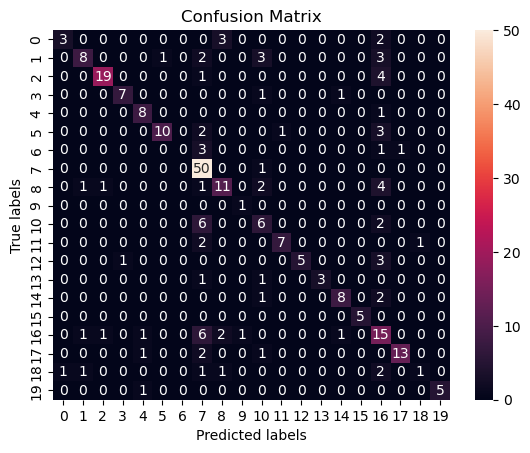

In [490]:
import seaborn as sbn
ax= plt.subplot()
sbn.heatmap(cmx, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
#ax.xaxis.set_ticklabels([3,4,5,6,7,8]); ax.yaxis.set_ticklabels([3,4,5,6,7,8]);

In [492]:
from sklearn.svm import SVC


In [494]:
# Initialize and train the SVM model
svm_model = SVC(kernel='linear')  # You can choose different kernels, such as 'linear', 'rbf', 'poly', etc.
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [495]:
y_pred = svm_model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
cmx=confusion_matrix(y_test, y_pred)
print(cmx)

Accuracy: 71.32%
Classification Report:
                      precision    recall  f1-score   support

         AI services       0.57      0.50      0.53         8
        About Japeto       0.80      0.47      0.59        17
                Apps       0.90      0.79      0.84        24
             Billing       0.70      0.78      0.74         9
          Compliance       0.67      0.67      0.67         9
             Contact       1.00      0.62      0.77        16
            Feedback       1.00      0.40      0.57         5
General conversation       0.72      0.98      0.83        51
         Japeto Chat       0.75      0.75      0.75        20
     Managed hosting       0.00      0.00      0.00         1
               Other       0.45      0.64      0.53        14
               Paige       0.56      0.50      0.53        10
        Partnerships       1.00      0.67      0.80         9
                 Pat       1.00      1.00      1.00         5
  Project management       0.

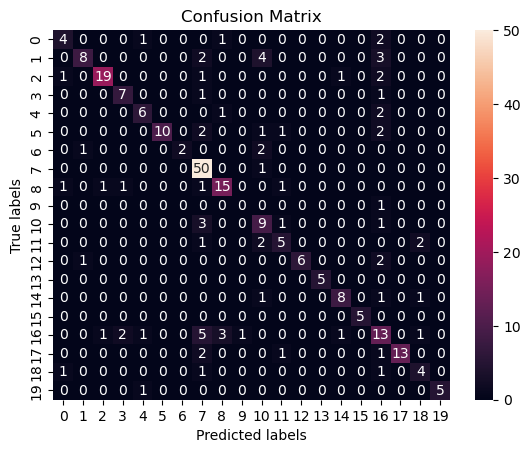

In [498]:
ax= plt.subplot()
sbn.heatmap(cmx, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 

In [500]:
from sklearn.model_selection import KFold, cross_val_score

scores = cross_val_score(svm_model,a,dataset["categories"], cv = 10)

print('Cross-validation scores:',scores)

Cross-validation scores: [0.72058824 0.73529412 0.75735294 0.73529412 0.73529412 0.72794118
 0.73529412 0.72058824 0.72592593 0.71851852]
